# **Case 1: Clamped BCs, Uniform Load**

See [1_formulation.ipynb](1_formulation.ipynb) for the formulation derivation and the table of plate elements compared.


In [2]:
from typing import Callable

import numpy as np
import matplotlib.pyplot as plt

import pyck as ck

FORMULATIONS = {
    "KL-1": ck.PlateKirchhoffLove1p,
    "RM-3": ck.PlateReissnerMindlin3p,
    "RM-D3": ck.PlateReissnerMindlinDispl3p,
    "RM-D2": ck.PlateReissnerMindlinDispl2p,
    "RM-D1": ck.PlateReissnerMindlin1p
}

In [3]:
def max_displacement(problem, solution, n_eval=81):
    """Compute the maximum reconstructed transverse displacement."""
    plate = problem.patches[0]
    element = problem.element
    u = np.asarray(solution)[:problem.num_physical_dofs]

    grid = np.linspace(0.0, 1.0, n_eval)
    uu, vv = np.meshgrid(grid, grid, indexing="xy")
    pts = np.column_stack([uu.ravel(), vv.ravel()])

    shape = ck.eval_shape_at(plate, pts, order=2)
    Nw = element._cpp_object.displacement_shape_matrix(shape)
    w = Nw @ u

    return float(np.max(np.abs(w)))


def center_displacement(problem, solution):
    """Compute the reconstructed transverse displacement at the plate center."""
    plate = problem.patches[0]
    element = problem.element
    u = np.asarray(solution)[:problem.num_physical_dofs]

    shape = ck.eval_shape_at(plate, np.array([[0.5, 0.5]]), order=2)
    Nw = element._cpp_object.displacement_shape_matrix(shape)
    return float(abs((Nw @ u)[0]))


def strain_energy(solution, K):
    """Compute the strain energy from the solution and stiffness matrix."""
    num_phys = K.shape[0]
    u_phys = solution[:num_phys]
    return 0.5 * np.dot(u_phys, K @ u_phys)


def external_work_energy(solution, F):
    """Compute the energy from the physical external load vector."""
    u_phys = np.asarray(solution)[:F.shape[0]]
    return 0.5 * float(np.dot(F, u_phys))

## **Case 1: Clamped BCs, Uniform Load**

Under a uniform load, the solution for the fully clamped Reissner-Mindlin plate has no known analytical solution. For this reason, we use the standard Reissner-Mindlin and Kirchhoff-Love formulations as numerical references.

In [4]:
# Plate dimensions (thick plate in the R/M regime)
L, W, t = 1.0, 1.0, 0.25

# Material properties
E, nu = 10.92, 0.3

# Load scaling
f0 = -10.0

def uniform_load(pts):
    return f0 * np.ones(pts.shape[0])

The reference solution is selected based on the slenderness ratio of the plate
- for **moderately thick plates**, $L/h < 100$, **RM-3** is used as the reference,
- for **thin plates**, $L/h \ge 100$, **KL-1** is used as the reference.

The treatment of the boundary conditions is also chosen according to the slenderness regime. In the thick-plate regime, Lagrange multipliers are used because of their accuracy and consistency. However, in the thin-plate regime, they may lead to conditioning issues. Therefore, penalty functions are used instead.

In [5]:
def apply_clamped_lagrange(problem, plate, quadrature=None):
    """Apply clamped boundary conditions using Lagrange Multipliers."""
    for side in ("u0", "u1", "v0", "v1"):
        cond = ck.LagrangeMultiplierCondition(
            boundary=plate.boundary(side),
            quadrature=quadrature,
            w_bar=0.0,
            phi_n_bar=0.0,
            phi_s_bar=0.0,
        )
        problem.add_condition(cond)

PENALTY_SCALE = 1.0e6

def apply_clamped_penalty(problem, plate, quadrature=None):
    """Applied clamped boundary conditions using Penalty Function."""
    Kb = problem.element.material.bending_stiffness()
    alpha_w = PENALTY_SCALE * Kb / L**3
    alpha_phi = PENALTY_SCALE * Kb / L
    
    for side in ("u0", "u1", "v0", "v1"):
        cond = ck.PenaltyCondition(
            plate.boundary(side), quadrature,
            alpha_w=alpha_w, w_bar=0.0,
            alpha_phi_n=alpha_phi, phi_n_bar=0.0,
            alpha_phi_s=alpha_phi, phi_s_bar=0.0,
        )
        problem.add_condition(cond)


def solve_clamped_plate(
    problem: ck.LinearElasticProblem,
    load_fn: Callable, 
    bc_type: str,
    load_quadrature=None,
    boundary_quadrature=None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Solve a single-patch clamped plate problem under a transverse load.

    Returns:
        Tuple of (solution vector, stiffness matrix, load vector).
    """
    plate = problem.patches[0]

    load = ck.conditions.create_load_condition(
        patch=plate, load_fn=load_fn, quadrature=load_quadrature
    )
    problem.add_condition(load)

    # Assemble before adding constraints
    K, F = problem.assemble()

    if bc_type == "penalty":
        apply_clamped_penalty(problem, plate, boundary_quadrature)
    elif bc_type == "lagrange":
        apply_clamped_lagrange(problem, plate, boundary_quadrature)
    else:
        raise ValueError("Invalid BC type")

    u = ck.solve(problem)
    return u, K, F

### **1.1. Slenderness Sweep**

Since the least continuity required for the single- and two-parameter Reissner-Mindlin elements is $C^2$, a polynomial degree $p=3$ will be used across all formulations for fair comparison.

In [6]:
PDEG = 3
NBASIS = 22

plate = ck.geometry.create_rectangle(nu=NBASIS, nv=NBASIS, deg=PDEG, l=L, w=W)
gauss2d = ck.GaussLegendre(PDEG + 1, dim=2)
gauss1d = ck.GaussLegendre(PDEG + 1, dim=1)

We perform a slenderness sweep to evaluate the performance of the formulation over a wide range of plate thicknesses. The slenderness ratio $L/h$ is varied from the thick-plate regime to the thin-plate limit, allowing us to assess whether the formulation remains accurate across different regimes.

$L/h$ is sampled logarithmically from $2$ to $10^8$ using 15 values. Since the plate length is fixed, increasing $L/h$ corresponds to decreasing the thickness $h = L/(L/h)$.

In [7]:
THIN_PLATE_SWITCH = 100.0
SLENDERNESS_VALUES = np.logspace(np.log10(2.0), 8.0, 15)

solutions = [{} for _ in SLENDERNESS_VALUES]

print("Clamped plate under uniform load")
print("Boundary enforcement: Lagrange multipliers for RM-3p reference.") 
print("Penalty with "
    f"alpha_w = {PENALTY_SCALE:.1e} Kb / L^3 and "
    f"alpha_phi = {PENALTY_SCALE:.1e} Kb / L"
)
print(
    f"{'L/h':>10} | {'Ref':>6} | {'BC':>7} | {'KL-1':>13} | {'RM-3':>13} | "
    f"{'RM-D3':>13} | {'RM-D2':>13} | {'RM-D1':>13}"
)
print("-" * 103)

for i, s in enumerate(SLENDERNESS_VALUES):
    # According to thickness, define material, BC type and reference model ---
    material = ck.material.create_plane_stress_2d(E, nu, L / s)
    bc_type = "penalty" if s > THIN_PLATE_SWITCH else "lagrange"
    ref_name = "RM-3" if s < THIN_PLATE_SWITCH else "KL-1"

    # Run simulation and store results ---------------------------------------
    row_results = {}
    for formulation in FORMULATIONS.keys():
        element_cls = FORMULATIONS[formulation]
        element = element_cls(material)
        problem = ck.LinearElasticProblem([plate], element, gauss2d)
        u, K, F = solve_clamped_plate(
            problem, uniform_load, bc_type, gauss2d, gauss1d
        )
        row_results[formulation] = {
            "w": center_displacement(problem, u),
            "U": external_work_energy(u, F),
        }

    # Compute relative values compared to reference solution -------------------
    ref_displ = row_results[ref_name]["w"]
    ref_strain = row_results[ref_name]["U"]

    row_values = {}
    for formulation in FORMULATIONS.keys():
        displ_ratio = row_results[formulation]["w"] / ref_displ
        strain_ratio = row_results[formulation]["U"] / ref_strain
        solutions[i][formulation] = {
            "displ_ratio": displ_ratio,
            "strain_ratio": strain_ratio
        }
        row_values[formulation] = f"{displ_ratio:.3f}/{strain_ratio:.3f}"

    row = (
        f"{s:10.2e} | {ref_name:>6} | {bc_type:>7} | "
        f"{row_values['KL-1']:>13} | {row_values['RM-3']:>13} | "
        f"{row_values['RM-D3']:>13} | {row_values['RM-D2']:>13} | "
        f"{row_values['RM-D1']:>13}"
    )
    print(row)

Clamped plate under uniform load
Boundary enforcement: Lagrange multipliers for RM-3p reference.
Penalty with alpha_w = 1.0e+06 Kb / L^3 and alpha_phi = 1.0e+06 Kb / L
       L/h |    Ref |      BC |          KL-1 |          RM-3 |         RM-D3 |         RM-D2 |         RM-D1
-------------------------------------------------------------------------------------------------------
  2.00e+00 |   RM-3 | lagrange |   0.191/0.132 |   1.000/1.000 |   1.000/1.000 |   0.993/0.987 |   0.067/0.008
  7.10e+00 |   RM-3 | lagrange |   0.732/0.643 |   1.000/1.000 |   1.000/1.000 |   0.999/0.997 |   0.419/0.241
  2.52e+01 |   RM-3 | lagrange |   0.970/0.955 |   1.000/1.000 |   1.000/1.000 |   1.000/1.000 |   0.777/0.675
  8.93e+01 |   RM-3 | lagrange |   0.998/0.996 |   1.000/1.000 |   1.000/1.000 |   1.000/1.000 |   0.862/0.795
  3.17e+02 |   KL-1 | penalty |   1.000/1.000 |   1.000/1.000 |   1.000/1.001 |   1.000/1.001 |   1.000/1.000
  1.12e+03 |   KL-1 | penalty |   1.000/1.000 |   0.999/0.995 | 

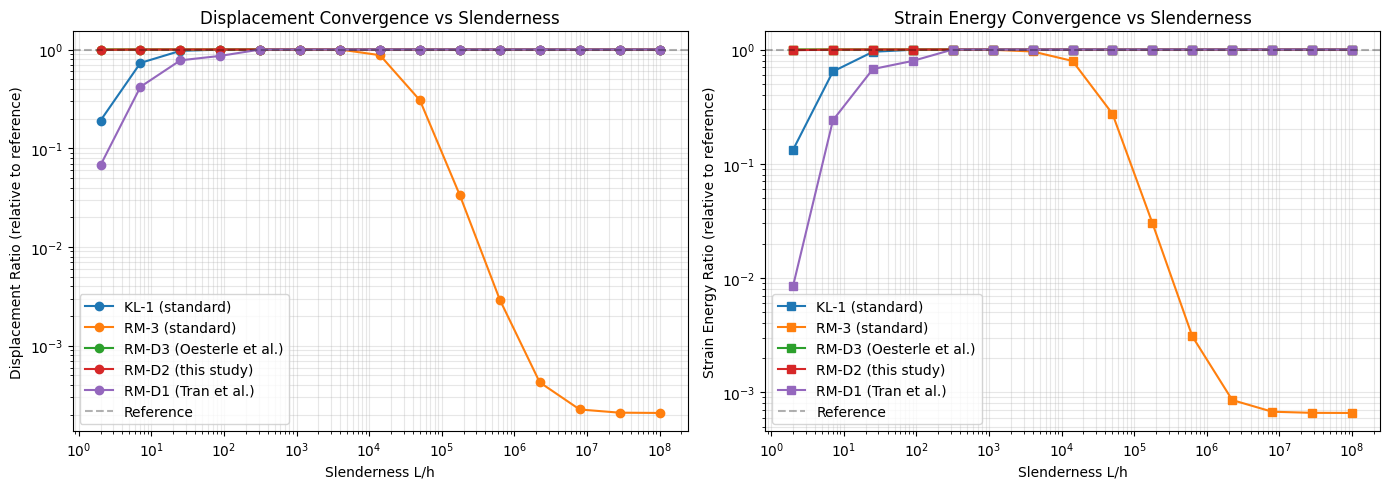

In [9]:
# Plot results ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

formulations_list = list(FORMULATIONS.keys())
displ_ratios = {f: [] for f in formulations_list}
strain_ratios = {f: [] for f in formulations_list}

for i, s in enumerate(SLENDERNESS_VALUES):
    for f in formulations_list:
        displ_ratios[f].append(solutions[i][f]["displ_ratio"])
        strain_ratios[f].append(solutions[i][f]["strain_ratio"])

legend_labels = {
    "KL-1": "KL-1 (standard)",
    "RM-3": "RM-3 (standard)",
    "RM-D3": "RM-D3 (Oesterle et al.)",
    "RM-D2": "RM-D2 (this study)",
    "RM-D1": "RM-D1 (Tran et al.)",
}

# Plot: displacement ratio
ax = axes[0]
for formulation in formulations_list:
    ax.loglog(SLENDERNESS_VALUES, displ_ratios[formulation], marker='o', label=legend_labels[formulation])
ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, label='Reference')
ax.set_xlabel("Slenderness L/h")
ax.set_ylabel("Displacement Ratio (relative to reference)")
ax.set_title("Displacement Convergence vs Slenderness")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

# Plot: strain energy ratio
ax = axes[1]
for formulation in formulations_list:
    ax.loglog(SLENDERNESS_VALUES, strain_ratios[formulation], marker='s', label=legend_labels[formulation])
ax.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, label='Reference')
ax.set_xlabel("Slenderness L/h")
ax.set_ylabel("Strain Energy Ratio (relative to reference)")
ax.set_title("Strain Energy Convergence vs Slenderness")
ax.legend()
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

### **1.2. Moderately-Thick Plate Convergence Study**

The RM-displ-2p formulation exhibits a slightly larger error than the other formulations at comparable mesh resolutions. To determine whether this discrepancy is intrinsic to the formulation or simply a consequence of insufficient refinement, we perform a dedicated mesh convergence study.

In [10]:
# Material and BC type for the convergence test ---------------------
SLENDERNESS = 3.0

convergence_mat = ck.material.create_plane_stress_2d(
    E, nu, L / SLENDERNESS
)
convergence_bc = "lagrange"

# Reference solution parameters ----------------------------------------
PDEG_CONV_REF = 5
NBASIS_CONV_REF = 48

ref_patch = ck.geometry.create_rectangle(
    nu=NBASIS_CONV_REF, nv=NBASIS_CONV_REF, 
    deg=PDEG_CONV_REF, l=L, w=W,
)

ref_gauss2d = ck.GaussLegendre(PDEG_CONV_REF + 1, dim=2)
ref_gauss1d = ck.GaussLegendre(PDEG_CONV_REF + 1, dim=1)
ref_element = FORMULATIONS["RM-3"](convergence_mat)
ref_problem = ck.LinearElasticProblem([ref_patch], ref_element, ref_gauss2d)

print("")
print("RM-displ-2p thick-plate mesh convergence under uniform load")
print(
    f"Reference: RM3, p={PDEG_CONV_REF}, n={NBASIS_CONV_REF}, "
    f"L/h={SLENDERNESS:g}; BC = {convergence_bc}",
    flush=True,
)

# Solve and postprocess -----------------------------------------------
ref_u, ref_K, ref_F = solve_clamped_plate(
    ref_problem, uniform_load, convergence_bc, ref_gauss2d, ref_gauss1d
)

ref_w = max_displacement(ref_problem, ref_u)
ref_U = strain_energy(ref_u, ref_K)


RM-displ-2p thick-plate mesh convergence under uniform load
Reference: RM3, p=5, n=48, L/h=3; BC = lagrange


In [11]:
# Refinement parameters
RMD2_CONVERGENCE_N = [8, 12, 18, 26, 34, 42]
PDEG_CONV = 3

convergence_rows = []
for i, n_basis in enumerate(RMD2_CONVERGENCE_N, start=1):
    print(
        f"[convergence {i:02d}/{len(RMD2_CONVERGENCE_N)}] "
        f"Solving RMD2 p={PDEG_CONV}, n={n_basis}",
        flush=True,
    )

    # Setup simulation for each refinement -------------------------------------
    patch_i = ck.geometry.create_rectangle(
        nu=n_basis, nv=n_basis, deg=PDEG_CONV, l=L, w=W
    )
    gauss2d_i = ck.GaussLegendre(PDEG_CONV + 1, dim=2)
    gauss1d_i = ck.GaussLegendre(PDEG_CONV + 1, dim=1)
    element_i = FORMULATIONS["RM-D2"](convergence_mat)
    problem_i = ck.LinearElasticProblem([patch_i], element_i, gauss2d_i)

    # Solve and postprocess ----------------------------------------------------
    u_i, K_i, F_i = solve_clamped_plate(
        problem_i, uniform_load, convergence_bc, gauss2d_i, gauss1d_i
    )

    w_i = max_displacement(problem_i, u_i)
    U_i = strain_energy(u_i, K_i)
    w_ratio = w_i / ref_w
    U_ratio = U_i / ref_U

    row = {
        "n": n_basis,
        "dofs": problem_i.num_physical_dofs,
        "w_ratio": w_ratio,
        "w_error": abs(w_ratio - 1.0),
        "U_ratio": U_ratio,
        "U_error": abs(U_ratio - 1.0),
    }
    convergence_rows.append(row)
    print(
        f"[convergence {i:02d}/{len(RMD2_CONVERGENCE_N)}] "
        f"done: wmax/ref={row['w_ratio']:.6f}, U/ref={row['U_ratio']:.6f}",
        flush=True,
    )

print(
    f"{'n':>5} | {'dofs':>7} | {'wmax/ref':>10} | {'w err':>10} | "
    f"{'U/ref':>10} | {'U err':>10}"
)
print("-" * 67)
for row in convergence_rows:
    print(
        f"{row['n']:5d} | "
        f"{row['dofs']:7d} | "
        f"{row['w_ratio']:10.6f} | "
        f"{row['w_error']:10.3e} | "
        f"{row['U_ratio']:10.6f} | "
        f"{row['U_error']:10.3e}"
    )

n_values = np.array([row["n"] for row in convergence_rows])
w_ratios = np.array([row["w_ratio"] for row in convergence_rows])
U_ratios = np.array([row["U_ratio"] for row in convergence_rows])

[convergence 01/6] Solving RMD2 p=3, n=8
[convergence 01/6] done: wmax/ref=0.958681, U/ref=0.901641
[convergence 02/6] Solving RMD2 p=3, n=12
[convergence 02/6] done: wmax/ref=0.986332, U/ref=0.967593
[convergence 03/6] Solving RMD2 p=3, n=18
[convergence 03/6] done: wmax/ref=0.994554, U/ref=0.986560
[convergence 04/6] Solving RMD2 p=3, n=26
[convergence 04/6] done: wmax/ref=0.997301, U/ref=0.993246
[convergence 05/6] Solving RMD2 p=3, n=34
[convergence 05/6] done: wmax/ref=0.998248, U/ref=0.995723
[convergence 06/6] Solving RMD2 p=3, n=42
[convergence 06/6] done: wmax/ref=0.998691, U/ref=0.996934
    n |    dofs |   wmax/ref |      w err |      U/ref |      U err
-------------------------------------------------------------------
    8 |     128 |   0.958681 |  4.132e-02 |   0.901641 |  9.836e-02
   12 |     288 |   0.986332 |  1.367e-02 |   0.967593 |  3.241e-02
   18 |     648 |   0.994554 |  5.446e-03 |   0.986560 |  1.344e-02
   26 |    1352 |   0.997301 |  2.699e-03 |   0.993246 

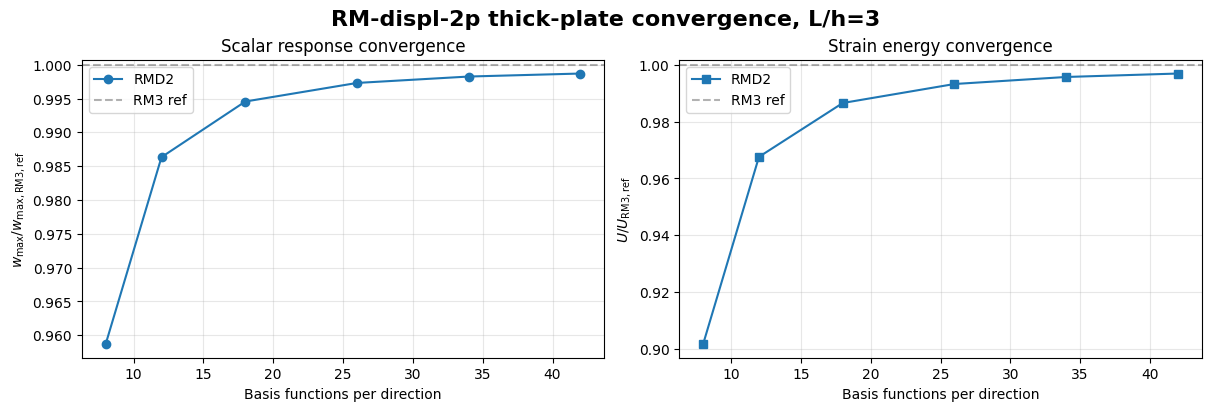

In [14]:
# Plot convergence study ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

axes[0].plot(n_values, w_ratios, "o-", label="RMD2")
axes[0].axhline(1.0, color="k", linestyle="--", alpha=0.3, label="RM3 ref")
axes[0].set_xlabel("Basis functions per direction")
axes[0].set_ylabel(r"$w_{\max} / w_{\max,\mathrm{RM3,ref}}$")
axes[0].set_title("Scalar response convergence")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(n_values, U_ratios, "s-", label="RMD2")
axes[1].axhline(1.0, color="k", linestyle="--", alpha=0.3, label="RM3 ref")
axes[1].set_xlabel("Basis functions per direction")
axes[1].set_ylabel(r"$U / U_{\mathrm{RM3,ref}}$")
axes[1].set_title("Strain energy convergence")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle(
    f"RM-displ-2p thick-plate convergence, L/h={SLENDERNESS:g}", 
    fontsize=16, fontweight="bold"
)
plt.show()

The results confirm that the error is refinement-related rather than formulation-related. Under mesh refinement, the `RM-D2` solution converges toward the refined `RM-3` reference, indicating that the formulation is consistent and that the observed discrepancy on coarser meshes is due to discretization error rather than an inherent modeling error.

### **1.3. Solenoidal Strain Component and Boundary Layer**

The scalar potential $\psi$ introduces the solenoidal part of the rotation and shear fields through $\nabla \times \psi$. This contribution is divergence-free by construction and is therefore not representable by a pure displacement gradient. It is especially important for boundary conditions that generate localized rotational corrections near constrained edges, such as clamped or partially constrained boundaries.

These localized corrections are the classical boundary-layer response: the rotation field changes rapidly near the boundary to satisfy the constraint, while the interior remains comparatively smooth. In the two-parameter formulation, $\psi$ provides exactly this missing rotational mode. For a scalar field normal to the plate, we use the convention

$$
\nabla \times \psi = \begin{bmatrix}
\partial \psi / \partial y \\
-\partial \psi / \partial x
\end{bmatrix}.
$$

The following plot runs separate `RM-D2` IGA simulations over several thick-plate slendernesses, each with its own material thickness. The scalar fields are plotted directly as recovered from the solution vectors, and the second row shows the induced rotation fields $\nabla \times \psi$. In Reissner-Mindlin plate theory the boundary layer is expected to be of order $h$, so the small dashed markers indicate one local thickness from each edge.


In [17]:
SOLENOIDAL_SLENDERNESSES = [3.0, 4.0, 7.0]
SOLENOIDAL_PDEG = 3
SOLENOIDAL_NBASIS = 42
SOLENOIDAL_BC = "lagrange"

n_plot = 121
grid = np.linspace(0.0, 1.0, n_plot)
uu, vv = np.meshgrid(grid, grid, indexing="xy")
pts = np.column_stack([uu.ravel(), vv.ravel()])
X = uu * L
Y = vv * W

solenoidal_fields = []
for slenderness in SOLENOIDAL_SLENDERNESSES:
    solenoidal_material = ck.material.create_plane_stress_2d(E, nu, L / slenderness)
    solenoidal_patch = ck.geometry.create_rectangle(
        nu=SOLENOIDAL_NBASIS,
        nv=SOLENOIDAL_NBASIS,
        deg=SOLENOIDAL_PDEG,
        l=L,
        w=W,
    )
    solenoidal_gauss2d = ck.GaussLegendre(SOLENOIDAL_PDEG + 1, dim=2)
    solenoidal_gauss1d = ck.GaussLegendre(SOLENOIDAL_PDEG + 1, dim=1)
    solenoidal_element = FORMULATIONS["RM-D2"](solenoidal_material)
    solenoidal_problem = ck.LinearElasticProblem(
        [solenoidal_patch], solenoidal_element, solenoidal_gauss2d
    )
    solenoidal_u, _, _ = solve_clamped_plate(
        solenoidal_problem,
        uniform_load,
        SOLENOIDAL_BC,
        solenoidal_gauss2d,
        solenoidal_gauss1d,
    )

    shape = ck.eval_shape_at(solenoidal_patch, pts, order=2)
    u_phys = np.asarray(solenoidal_u)[:solenoidal_problem.num_physical_dofs]
    psi_coeff = u_phys[1::2]

    psi = np.asarray(shape[0] @ psi_coeff).reshape(uu.shape)
    psi_x = np.asarray(shape[1] @ psi_coeff).reshape(uu.shape)
    psi_y = np.asarray(shape[2] @ psi_coeff).reshape(uu.shape)
    rot_x = psi_y
    rot_y = -psi_x
    rot_norm = np.sqrt(rot_x**2 + rot_y**2)

    solenoidal_fields.append(
        {
            "slenderness": slenderness,
            "psi": psi,
            "rot_x": rot_x,
            "rot_y": rot_y,
            "rot_norm": rot_norm,
            "layer_width": L / slenderness,
        }
    )

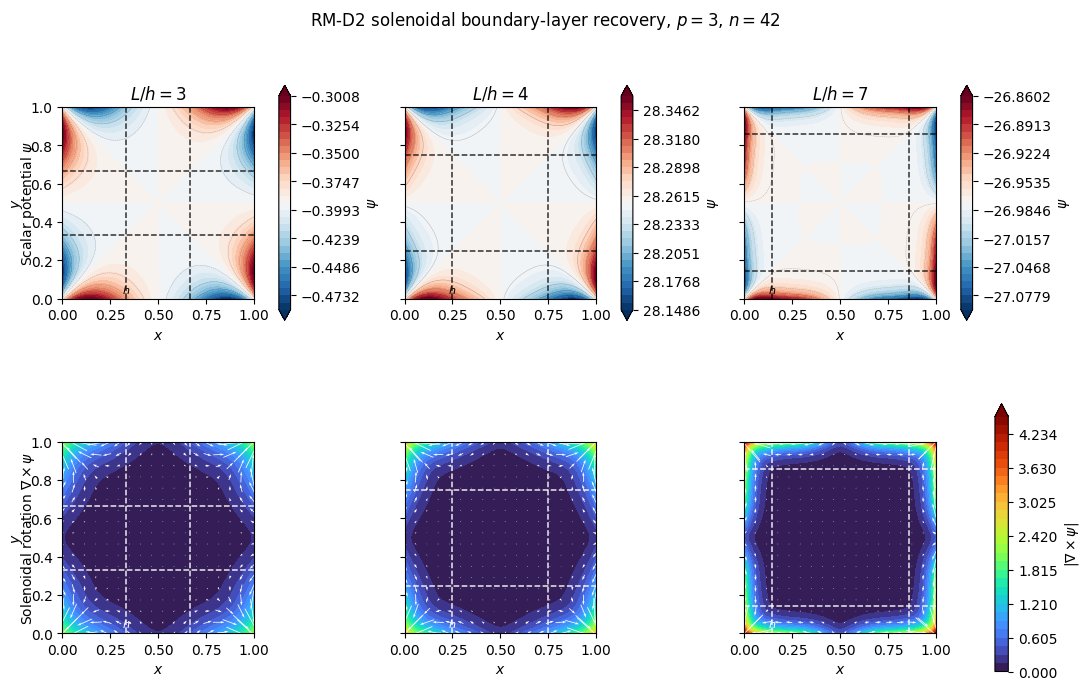

In [18]:
# Plot boundary layers ------------------------------------------------------
fig, axes = plt.subplots(
    2,
    len(SOLENOIDAL_SLENDERNESSES),
    figsize=(3.6 * len(SOLENOIDAL_SLENDERNESSES), 7.0),
    constrained_layout=True,
)

rot_abs_max = max(np.max(field["rot_norm"]) for field in solenoidal_fields)
rot_levels = np.linspace(0.0, rot_abs_max, 31)
skip = 7

for col, field in enumerate(solenoidal_fields):
    slenderness = field["slenderness"]
    layer_width_x = min(field["layer_width"], 0.5 * L)
    layer_width_y = min(field["layer_width"], 0.5 * W)
    psi_min = np.min(field["psi"])
    psi_max = np.max(field["psi"])
    if np.isclose(psi_min, psi_max):
        psi_min -= 0.5
        psi_max += 0.5
    psi_levels = np.linspace(psi_min, psi_max, 31)

    ax_psi = axes[0, col]
    contour = ax_psi.contourf(
        X, Y, field["psi"], levels=psi_levels, cmap="RdBu_r", extend="both"
    )
    ax_psi.contour(X, Y, field["psi"], levels=9, colors="k", linewidths=0.3, alpha=0.3)
    fig.colorbar(contour, ax=ax_psi, shrink=0.72, label=r"$\psi$")
    ax_psi.axvline(layer_width_x, color="black", linestyle="--", linewidth=1.1, alpha=0.8)
    ax_psi.axvline(L - layer_width_x, color="black", linestyle="--", linewidth=1.1, alpha=0.8)
    ax_psi.axhline(layer_width_y, color="black", linestyle="--", linewidth=1.1, alpha=0.8)
    ax_psi.axhline(W - layer_width_y, color="black", linestyle="--", linewidth=1.1, alpha=0.8)
    ax_psi.text(
        layer_width_x,
        0.02 * W,
        r"$h$",
        ha="center",
        va="bottom",
        fontsize=8,
        color="black",
    )
    ax_psi.set_title(rf"$L/h={slenderness:g}$")
    ax_psi.set_aspect("equal")
    ax_psi.set_xlabel(r"$x$")
    if col == 0:
        ax_psi.set_ylabel(r"$y$")
    else:
        ax_psi.set_yticklabels([])

    ax_rot = axes[1, col]
    speed = ax_rot.contourf(
        X, Y, field["rot_norm"], levels=rot_levels, cmap="turbo", extend="max"
    )
    ax_rot.quiver(
        X[::skip, ::skip],
        Y[::skip, ::skip],
        field["rot_x"][::skip, ::skip],
        field["rot_y"][::skip, ::skip],
        color="white",
        pivot="mid",
        scale_units="xy",
        width=0.004,
    )
    ax_rot.axvline(layer_width_x, color="white", linestyle="--", linewidth=1.1, alpha=0.9)
    ax_rot.axvline(L - layer_width_x, color="white", linestyle="--", linewidth=1.1, alpha=0.9)
    ax_rot.axhline(layer_width_y, color="white", linestyle="--", linewidth=1.1, alpha=0.9)
    ax_rot.axhline(W - layer_width_y, color="white", linestyle="--", linewidth=1.1, alpha=0.9)
    ax_rot.text(
        layer_width_x,
        0.02 * W,
        r"$h$",
        ha="center",
        va="bottom",
        fontsize=8,
        color="white",
    )
    ax_rot.set_aspect("equal")
    ax_rot.set_xlabel(r"$x$")
    if col == 0:
        ax_rot.set_ylabel(r"$y$")
    else:
        ax_rot.set_yticklabels([])

axes[0, 0].text(
    -0.18,
    0.5,
    r"Scalar potential $\psi$",
    transform=axes[0, 0].transAxes,
    rotation=90,
    ha="center",
    va="center",
)
axes[1, 0].text(
    -0.18,
    0.5,
    r"Solenoidal rotation $\nabla \times \psi$",
    transform=axes[1, 0].transAxes,
    rotation=90,
    ha="center",
    va="center",
)

fig.colorbar(speed, ax=axes[1, :], shrink=0.82, label=r"$|\nabla \times \psi|$")
fig.suptitle(
    rf"$\mathrm{{RM}}$-$\mathrm{{D}}2$ solenoidal boundary-layer recovery, "
    rf"$p={SOLENOIDAL_PDEG}$, $n={SOLENOIDAL_NBASIS}$"
)

plt.show()
